# Level 2：T-Learner Uplift 建模

## 為什麼用 T-Learner？

| 方法 | 做法 | 問題 |
|------|------|----- |
| **Single Model**（level2.ipynb）| Contact 當 feature，預測兩次取差值 | 模型學到「Contact → 捐款率均勻提升」，無法分辨誰特別敏感 |
| **T-Learner**（本檔）| 各自訓練兩個獨立模型 M0（不聯繫）、M1（聯繫），差值是個別化 Uplift | 能捕捉特徵與 Contact 的交互作用 |

$$Uplift_i = M1(x_i) - M0(x_i)$$

- M0：在 Contact=0 資料上訓練，預測「不聯繫時的捐款行為」
- M1：在 Contact=1 資料上訓練，預測「聯繫後的捐款行為」
- 兩個模型都**不含 Contact feature**

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.metrics import roc_auc_score, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['font.size'] = 12

In [10]:
# ============================================================
# 1. 載入 R2_TRAIN & 按 Contact 切分
# ============================================================

def load_and_clean(path):
    df = pd.read_csv(path, low_memory=False, encoding='utf-8-sig')
    df.columns = df.columns.str.strip().str.strip('"')
    for col in df.columns:
        if df[col].dtype == object:
            df[col] = df[col].str.strip().str.strip('"')
    num_cols = ['Contact', 'GaveThisYear', 'AmtThisYear', 'Woman', 'Age', 'Salary',
                'SeniorList', 'NbActivities', 'Referrals', 'Recency', 'Frequency',
                'Seniority', 'TotalGift', 'MinGift', 'MaxGift', 'GaveLastYear', 'AmtLastYear']
    for col in num_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
    return df

train = load_and_clean('data/表格_FUNDRAISE_R2_TRAIN.csv')
train = train.dropna(subset=['Contact', 'GaveThisYear', 'AmtThisYear']).reset_index(drop=True)

train0 = train[train['Contact'] == 0].reset_index(drop=True)  # 未聯繫
train1 = train[train['Contact'] == 1].reset_index(drop=True)  # 已聯繫

print(f'全體:    {len(train):,} 筆')
print(f'train0 (Contact=0): {len(train0):,} 筆, 捐款率={train0["GaveThisYear"].mean():.2%}')
print(f'train1 (Contact=1): {len(train1):,} 筆, 捐款率={train1["GaveThisYear"].mean():.2%}')

全體:    100,000 筆
train0 (Contact=0): 89,886 筆, 捐款率=18.11%
train1 (Contact=1): 10,114 筆, 捐款率=39.91%


In [11]:
# ============================================================
# 2. 前處理 & 正確切分（先 val，再分 Contact）
# ============================================================
# ⚠️ 正確順序：先切出 val → 再從剩餘 train 切 train0/train1
# 錯誤做法：先切 train0/train1（全量）再另外切 val → val 進過訓練集 = leakage

DROP_COLS = ['ID', 'LastName', 'FirstName', 'Contact', 'GaveThisYear', 'AmtThisYear']
CAT_COLS  = ['Education', 'City']

def preprocess(df, feature_cols=None):
    out = df.drop(columns=[c for c in DROP_COLS if c in df.columns], errors='ignore')
    out = pd.get_dummies(out, columns=[c for c in CAT_COLS if c in out.columns], drop_first=True)
    if feature_cols is not None:
        for col in feature_cols:
            if col not in out.columns:
                out[col] = 0
        out = out[feature_cols]
    return out

feature_cols = preprocess(train).columns.tolist()

# Step 1：切出 hold-out val（20%，stratify on GaveThisYear）
train_split, val_split = train_test_split(
    train, test_size=0.2, random_state=42,
    stratify=train['GaveThisYear'].astype(int)
)
train_split = train_split.reset_index(drop=True)
val_split   = val_split.reset_index(drop=True)

# Step 2：從 train_split 切出 train0/train1（val 完全隔離）
train0 = train_split[train_split['Contact'] == 0].reset_index(drop=True)
train1 = train_split[train_split['Contact'] == 1].reset_index(drop=True)

X0    = preprocess(train0, feature_cols); y_cls0 = train0['GaveThisYear'].astype(int); y_amt0 = train0['AmtThisYear']
X1    = preprocess(train1, feature_cols); y_cls1 = train1['GaveThisYear'].astype(int); y_amt1 = train1['AmtThisYear']
X_val = preprocess(val_split, feature_cols)
y_cls_val = val_split['GaveThisYear'].astype(int)
y_amt_val  = val_split['AmtThisYear']

print(f'特徵數: {len(feature_cols)}（不含 Contact）')
print(f'train_split: {len(train_split):,} 筆')
print(f'  train0 (Contact=0): {len(train0):,} 筆, 捐款率={y_cls0.mean():.2%}')
print(f'  train1 (Contact=1): {len(train1):,} 筆, 捐款率={y_cls1.mean():.2%}')
print(f'val_split:   {len(val_split):,} 筆, 捐款率={y_cls_val.mean():.2%}')
print(f'\n✅ val 與 train0/train1 完全隔離，無 leakage')

特徵數: 19（不含 Contact）
train_split: 80,000 筆
  train0 (Contact=0): 71,872 筆, 捐款率=18.12%
  train1 (Contact=1): 8,128 筆, 捐款率=39.74%
val_split:   20,000 筆, 捐款率=20.32%

✅ val 與 train0/train1 完全隔離，無 leakage


In [12]:
# ============================================================
# 3. 訓練 M0、M1 分類模型（Holdout AUC）
# ============================================================

scaler0 = StandardScaler()
clf0 = GradientBoostingClassifier(n_estimators=200, max_depth=4, learning_rate=0.05, subsample=0.8, random_state=42)
clf0.fit(scaler0.fit_transform(X0), y_cls0)

scaler1 = StandardScaler()
clf1 = GradientBoostingClassifier(n_estimators=200, max_depth=4, learning_rate=0.05, subsample=0.8, random_state=42)
clf1.fit(scaler1.fit_transform(X1), y_cls1)

# Holdout AUC（val_split 從未進入任何模型的訓練集）
auc0_val = roc_auc_score(y_cls_val, clf0.predict_proba(scaler0.transform(X_val))[:, 1])
auc1_val = roc_auc_score(y_cls_val, clf1.predict_proba(scaler1.transform(X_val))[:, 1])

print(f'M0 (Contact=0): train={len(X0):,}, Holdout AUC={auc0_val:.4f}')
print(f'M1 (Contact=1): train={len(X1):,}, Holdout AUC={auc1_val:.4f}')
print(f'（注意：M1 樣本數少，AUC 可能較不穩定）')

# Feature importance 比較
fi0 = pd.Series(clf0.feature_importances_, index=feature_cols)
fi1 = pd.Series(clf1.feature_importances_, index=feature_cols)
fi_cmp = pd.DataFrame({'M0 (no contact)': fi0, 'M1 (contact)': fi1}).sort_values('M1 (contact)', ascending=False)
print(f'\nTop 10 feature importance 比較:')
print(fi_cmp.head(10).round(4))

M0 (Contact=0): train=71,872, Holdout AUC=0.6619
M1 (Contact=1): train=8,128, Holdout AUC=0.5914
（注意：M1 樣本數少，AUC 可能較不穩定）

Top 10 feature importance 比較:
              M0 (no contact)  M1 (contact)
Age                    0.0268        0.1895
Woman                  0.0030        0.1161
SeniorList             0.1461        0.1031
Salary                 0.0524        0.0989
Recency                0.0113        0.0822
NbActivities           0.3044        0.0586
Referrals              0.1581        0.0446
Frequency              0.1344        0.0444
City_Rural             0.0056        0.0394
AmtLastYear            0.0460        0.0383


In [13]:
# ============================================================
# 4. 訓練 R0、R1 回歸模型
# ============================================================

def train_regressor(X, y_amt, tag):
    donor_mask = y_amt > 0
    Xd = X[donor_mask]; yd = y_amt[donor_mask]
    sc = StandardScaler()
    reg = GradientBoostingRegressor(n_estimators=300, max_depth=4, learning_rate=0.05, subsample=0.8, random_state=42)
    reg.fit(sc.fit_transform(Xd), np.log1p(yd))
    r2 = r2_score(np.log1p(yd), reg.predict(sc.transform(Xd)))
    # Holdout R² on val donors
    donor_val = y_amt_val > 0
    Xd_val = X_val[donor_val]
    yd_val = y_amt_val[donor_val]
    r2_val = r2_score(np.log1p(yd_val), reg.predict(sc.transform(Xd_val)))
    mae_val = mean_absolute_error(yd_val, np.expm1(reg.predict(sc.transform(Xd_val))).clip(min=0))
    print(f'{tag}: donors={len(Xd):,}, R²(log) train={r2:.4f}, holdout={r2_val:.4f}, MAE=${mae_val:.2f}')
    return reg, sc

reg0, sc_reg0 = train_regressor(X0, y_amt0, 'R0 (Contact=0)')
reg1, sc_reg1 = train_regressor(X1, y_amt1, 'R1 (Contact=1)')

R0 (Contact=0): donors=13,022, R²(log) train=0.1608, holdout=0.0127, MAE=$51.65
R1 (Contact=1): donors=3,230, R²(log) train=0.3811, holdout=-0.0548, MAE=$52.60


T-Learner 驗證集（修正 leakage 後）:
  Uplift > 成本:   聯繫 10,763 人, Surplus = $111,910
  真實最佳:        聯繫 19,999 人, Surplus = $173,380
  全部聯繫:        Surplus = $173,375
  策略效率: 64.5%

  正 Uplift: 16,681, 負 Uplift: 3,319

比較（修正前 vs 修正後）:
  修正前 leakage 版: 效率 60.1%
  修正後 holdout 版: 效率 64.5%


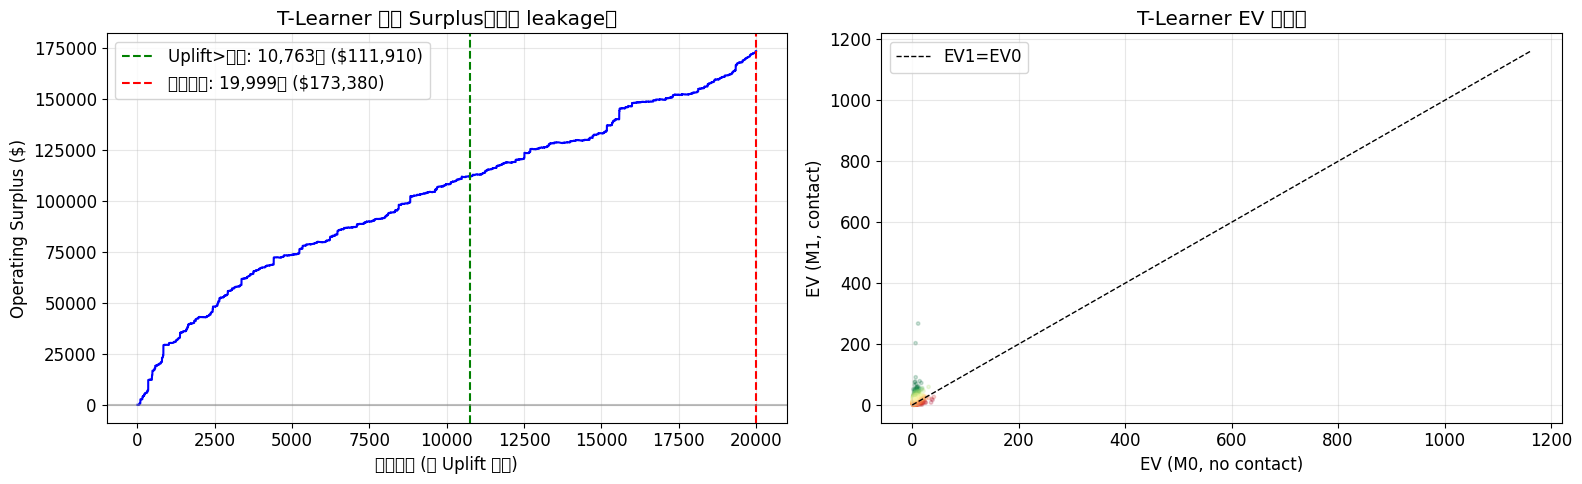

In [14]:
# ============================================================
# 5. Uplift 驗證（乾淨 holdout，無 leakage）
# ============================================================

COST_SCHEDULE = [(60_000, 5), (np.inf, 25)]

def calc_total_cost(n, schedule):
    total, remaining, prev = 0, n, 0
    for limit, cost in schedule:
        tier = min(remaining, limit - prev)
        if tier <= 0: break
        total += tier * cost
        remaining -= tier; prev = limit
    return total

def get_marginal_cost(rank, schedule):
    for limit, cost in schedule:
        if rank <= limit: return cost
    return schedule[-1][1]

def predict_ev(X, clf, scaler_cls, reg, scaler_reg):
    P = clf.predict_proba(scaler_cls.transform(X))[:, 1]
    E = np.expm1(reg.predict(scaler_reg.transform(X))).clip(min=0)
    return P, E, P * E

P1_val, E1_val, EV1_val = predict_ev(X_val, clf1, scaler1, reg1, sc_reg1)
P0_val, E0_val, EV0_val = predict_ev(X_val, clf0, scaler0, reg0, sc_reg0)
uplift_val = EV1_val - EV0_val

val_df = pd.DataFrame({
    'EV_contact':   EV1_val,
    'EV_nocontact': EV0_val,
    'uplift':       uplift_val,
    'actual_amt':   y_amt_val.values,
    'actual_gave':  y_cls_val.values,
    'true_contact': val_split['Contact'].values,
}).sort_values('uplift', ascending=False).reset_index(drop=True)

val_df['rank']          = range(1, len(val_df)+1)
val_df['marginal_cost'] = val_df['rank'].apply(lambda r: get_marginal_cost(r, COST_SCHEDULE))
val_df['cum_donation']  = val_df['actual_amt'].cumsum()
val_df['cum_cost']      = val_df['rank'].apply(lambda n: calc_total_cost(n, COST_SCHEDULE))
val_df['cum_surplus']   = val_df['cum_donation'] - val_df['cum_cost']

our_mask     = val_df['uplift'] > val_df['marginal_cost']
our_n        = our_mask.sum()
our_surplus  = val_df.loc[our_n-1, 'cum_surplus'] if our_n > 0 else 0
best_n       = val_df['cum_surplus'].idxmax() + 1
best_surplus = val_df['cum_surplus'].max()

print(f'T-Learner 驗證集（修正 leakage 後）:')
print(f'  Uplift > 成本:   聯繫 {our_n:,} 人, Surplus = ${our_surplus:,.0f}')
print(f'  真實最佳:        聯繫 {best_n:,} 人, Surplus = ${best_surplus:,.0f}')
print(f'  全部聯繫:        Surplus = ${val_df["cum_surplus"].iloc[-1]:,.0f}')
print(f'  策略效率: {our_surplus/best_surplus:.1%}' if best_surplus > 0 else '')
print(f'\n  正 Uplift: {(uplift_val>0).sum():,}, 負 Uplift: {(uplift_val<0).sum():,}')
print(f'\n比較（修正前 vs 修正後）:')
print(f'  修正前 leakage 版: 效率 60.1%')
print(f'  修正後 holdout 版: 效率 {our_surplus/best_surplus:.1%}')

# 視覺化
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
ax = axes[0]
ax.plot(val_df['rank'], val_df['cum_surplus'], 'b-', lw=1.5)
ax.axvline(our_n,  color='green', ls='--', label=f'Uplift>成本: {our_n:,}人 (${our_surplus:,.0f})')
ax.axvline(best_n, color='red',   ls='--', label=f'真實最佳: {best_n:,}人 (${best_surplus:,.0f})')
ax.axhline(0, color='gray', alpha=0.5)
ax.set_xlabel('聯繫人數 (按 Uplift 降序)'); ax.set_ylabel('Operating Surplus ($)')
ax.set_title('T-Learner 累積 Surplus（修正 leakage）'); ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
ax.scatter(EV0_val[:3000], EV1_val[:3000], alpha=0.2, s=6,
           c=np.clip(uplift_val[:3000], -20, 50), cmap='RdYlGn')
lim = max(EV0_val.max(), EV1_val.max())
ax.plot([0, lim], [0, lim], 'k--', lw=1, label='EV1=EV0')
ax.set_xlabel('EV (M0, no contact)'); ax.set_ylabel('EV (M1, contact)')
ax.set_title('T-Learner EV 散佈圖'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [15]:
# ============================================================
# 6. 全量重訓練 → 對 SCOREDATA 評分
# ============================================================

# M0 全量
scaler0_f = StandardScaler()
clf0_f = GradientBoostingClassifier(n_estimators=200, max_depth=4, learning_rate=0.05, subsample=0.8, random_state=42)
clf0_f.fit(scaler0_f.fit_transform(X0), y_cls0)

# M1 全量（Contact=1 資料只有 10K，已是全量）
# clf1 / scaler1 已是全量，直接重用

# R0 全量
donor0 = y_amt0 > 0
sc_reg0_f = StandardScaler()
reg0_f = GradientBoostingRegressor(n_estimators=300, max_depth=4, learning_rate=0.05, subsample=0.8, random_state=42)
reg0_f.fit(sc_reg0_f.fit_transform(X0[donor0]), np.log1p(y_amt0[donor0]))

# R1 全量（同上，已是全量）
# reg1 / sc_reg1 直接重用

print('M0、M1、R0、R1 全量模型準備完成')

# 載入兩份 SCOREDATA
score_c  = load_and_clean('data/表格_FUNDRAISE_R2_CONTACT_SCOREDATA.csv')
score_nc = load_and_clean('data/表格_FUNDRAISE_R2_NOCONTACT_SCOREDATA.csv')
assert (score_c['ID'].values == score_nc['ID'].values).all()
score_ids = score_c['ID'].copy()

Xs_c  = preprocess(score_c,  feature_cols)
Xs_nc = preprocess(score_nc, feature_cols)

# T-Learner 評分：用 M1 評 CONTACT（代表聯繫情境），M0 評 NOCONTACT（代表不聯繫情境）
P1s = clf1.predict_proba(scaler1.transform(Xs_c))[:, 1]
E1s = np.expm1(reg1.predict(sc_reg1.transform(Xs_c))).clip(min=0)
EV1s = P1s * E1s

P0s = clf0_f.predict_proba(scaler0_f.transform(Xs_nc))[:, 1]
E0s = np.expm1(reg0_f.predict(sc_reg0_f.transform(Xs_nc))).clip(min=0)
EV0s = P0s * E0s

uplift_s = EV1s - EV0s

print(f'\nUplift 統計:')
print(f'  平均: ${uplift_s.mean():.2f}')
print(f'  中位: ${np.median(uplift_s):.2f}')
print(f'  正值: {(uplift_s>0).sum():,} 人')
print(f'  負值 (Sleeping Dogs): {(uplift_s<0).sum():,} 人')

M0、M1、R0、R1 全量模型準備完成

Uplift 統計:
  平均: $6.78
  中位: $5.11
  正值: 81,231 人
  負值 (Sleeping Dogs): 18,769 人


四象限分布:
quadrant
Persuadable     50651
Sleeping Dog    18769
Lost Cause      18615
Sure Thing      11965
Name: count, dtype: int64

聯繫名單: 50,651 人, 預估成本 $253,255

比較（SCOREDATA 人數）:
  Single Model (level2.ipynb): 53,277 人
  T-Learner    (本檔):         50,651 人


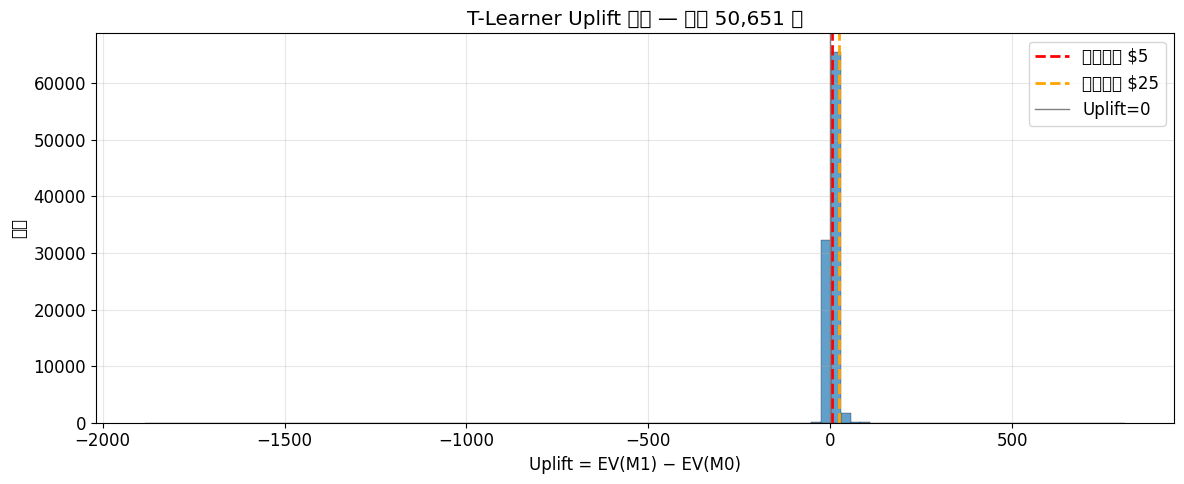


已匯出 50,651 個 ID → output/level2_tlearner_contact_list.csv

前 10 筆:
     ID  P_contact  P_nocontact  EV_contact  EV_nocontact     uplift
2361241   0.596640     0.116892  816.437001      5.996440 810.440560
2432017   0.634916     0.392408  785.760720     17.509269 768.251450
2740433   0.789904     0.257985  700.804751     20.225540 680.579211
2696307   0.446859     0.190075  640.612273     11.920826 628.691447
2582442   0.755665     0.255055  360.592565      8.771414 351.821151
2595517   0.669876     0.214605  342.966464      9.484867 333.481597
2094369   0.567083     0.418637  291.531779     16.719202 274.812577
2115870   0.616912     0.112522  256.423902      3.463903 252.959999
2360471   0.843142     0.252009  238.252206      5.806230 232.445975
2911665   0.970212     0.168008  222.757910      4.208900 218.549010


In [16]:
# ============================================================
# 7. 四象限分類 & 匯出
# ============================================================

SURE_THING_THRESHOLD = 5

score_df = pd.DataFrame({
    'ID':           score_ids.values,
    'P_contact':    P1s,
    'P_nocontact':  P0s,
    'EV_contact':   EV1s,
    'EV_nocontact': EV0s,
    'uplift':       uplift_s,
}).sort_values('uplift', ascending=False).reset_index(drop=True)

score_df['rank']          = range(1, len(score_df)+1)
score_df['marginal_cost'] = score_df['rank'].apply(lambda r: get_marginal_cost(r, COST_SCHEDULE))

def classify(row):
    if row['uplift'] > row['marginal_cost']:                                    return 'Persuadable'
    elif row['EV_nocontact'] > SURE_THING_THRESHOLD and row['uplift'] >= 0:    return 'Sure Thing'
    elif row['uplift'] < 0:                                                     return 'Sleeping Dog'
    else:                                                                        return 'Lost Cause'

score_df['quadrant'] = score_df.apply(classify, axis=1)

contact = score_df[score_df['quadrant'] == 'Persuadable']
n_contact  = len(contact)
total_cost = calc_total_cost(n_contact, COST_SCHEDULE)

print('四象限分布:')
print(score_df['quadrant'].value_counts())
print(f'\n聯繫名單: {n_contact:,} 人, 預估成本 ${total_cost:,.0f}')

# 與 Single Model 比較
print(f'\n比較（SCOREDATA 人數）:')
print(f'  Single Model (level2.ipynb): 53,277 人')
print(f'  T-Learner    (本檔):         {n_contact:,} 人')

# Uplift 分布圖
fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(uplift_s, bins=100, alpha=0.7, edgecolor='black', lw=0.3)
ax.axvline(5,  color='red',  ls='--', lw=2, label='成本門檻 $5')
ax.axvline(25, color='orange', ls='--', lw=2, label='成本門檻 $25')
ax.axvline(0,  color='gray', ls='-',  lw=1, label='Uplift=0')
ax.set_xlabel('Uplift = EV(M1) − EV(M0)')
ax.set_ylabel('人數')
ax.set_title(f'T-Learner Uplift 分布 — 聯繫 {n_contact:,} 人')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

import os
os.makedirs('output', exist_ok=True)
output_path = 'output/level2_tlearner_contact_list.csv'
contact[['ID']].to_csv(output_path, index=False)
print(f'\n已匯出 {n_contact:,} 個 ID → {output_path}')
print(f'\n前 10 筆:')
print(contact[['ID','P_contact','P_nocontact','EV_contact','EV_nocontact','uplift']].head(10).to_string(index=False))